C:\Users\pmlbl\AppData\Roaming\Python\Python312\site-packages\pymeasure\instruments\generic_types.py:110: FutureWarning: It is not known whether this device support SCPI commands or not. Please inform the pymeasure maintainers if you know the answer.
  warn("It is not known whether this device support SCPI commands or not. Please inform "


Text(0, 0.5, 'Current (A)')

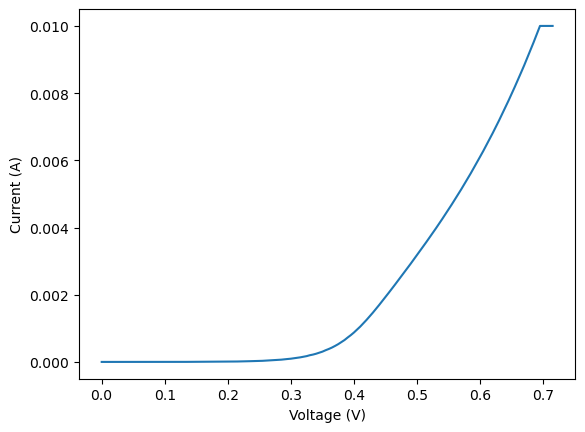

In [ ]:
from pymeasure.instruments.agilent import Agilent4156
import pyvisa
import matplotlib.pyplot as plt

# explicitly define r/w terminations; set sufficiently large timeout or None.
smu = Agilent4156("GPIB0::2::INSTR", read_termination = '\n', write_termination = '\n',timeout=None)
#print(pyvisa.ResourceManager().list_resources())
heatV = 5
sample = 'D00'     
path = 'C:\\Users\\pmlbl\\OneDrive\\Documents\\PythonScripts\\Data\\20241118\\{}'.format(sample)

# # reset the instrument
# smu.reset()

# # define configuration file for instrument and load config
# smu.configure("configuration_file.json")

# # save data variables, some or all of which are defined in the json config file.
# smu.save(['VC', 'IC', 'VB', 'IB'])

# # take measurements
status = smu.measure()

# measured data is a pandas dataframe and can be exported to csv.
data = smu.get_data(path +'\\t{}.csv'.format(heatV))
#data
plt.plot(data.VF, data.IF)
plt.xlabel('Voltage (V)')
plt.ylabel('Current (A)')

C:\Users\pmlbl\AppData\Local\Temp\ipykernel_2620\1924286352.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = plt.cm.get_cmap('seismic')


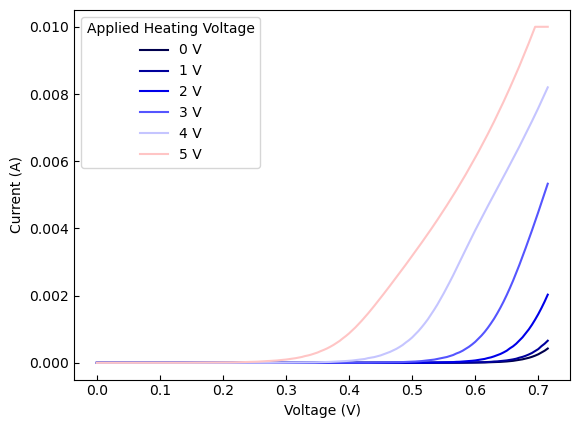

: 

In [ ]:
#test plotter
import pandas as pd
import os
import numpy as np

#Define file directory
dir = os.listdir( path )

fig, ax=plt.subplots()

# Get the Viridis colormap
viridis = plt.cm.get_cmap('seismic')

# Generate some sample values between 0 and 1
values = np.linspace(0, 1, 10)

# Get the RGB values for each sample value
rgb_values = viridis(values)
i=0
for file in dir:
   #Iterate over csv files in direcotry and add to plot
   if file.endswith(('.csv')):
      df = pd.read_csv(path+'\\'+file)
      ax.plot(df.VF,df.IF,label='{} V'.format(file[1]),color=rgb_values[i])
      ax.set_xlabel('Voltage (V)')
      ax.set_ylabel('Current (A)')
      #ax.set_ylim(1E-7,1E0)
      ax.tick_params(direction='in')
      ax.legend(title='Applied Heating Voltage')
      i+=1
   else:
      pass

In [ ]:
1V 0.089A
2V 0.177A
3V 0.261A
4V 0.339A
5V 0.400A

In [104]:
print(dir)

['D00_Initial_Test_1V.png', 'D00_Initial_Test_2V.png', 'D00_Initial_Test_3V.png', 'D00_Initial_Test_4V.png', 'D00_Initial_Test_5V.png', 'output.png', 't0.csv', 't1.csv', 't2.csv', 't3.csv', 't4.csv', 't5.csv']
